In [1]:
%load_ext cython

In [2]:
%%cython
# Cython code for MOACP runner: 10 runs, each run of 100 iterations, matching your C code logic

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Globals that reset per run
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size):
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    free(remplace)

def run_moacp(instance_file, weights_file, nbitems, num_objectives, output_file):
    """
    Run MOACP for a given instance, weights file, item count, objectives, and output file.
    Output is written to `output_file` (same format as C code).
    Performs 10 runs, each run of 100 iterations. Results are appended to output_file.
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    alpha = 10
    paretoIni = 28000

    NBL = 100
    NRUNS = 10

    for run in range(1, NRUNS+1):
        # FIX: set these at the start of each run
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives

        print(f"RUN {run}/{NRUNS} -- {instance_file.decode()} nbitems={ni} nf={nf} => {output_file}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0

        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)

        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)

        it = 0
        while it < NBL:
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            Indicator_local_search1(solutions, archive, alpha)
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        # Write Pareto front after each run (append mode)
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")  # match C code: separate runs
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")

        complete_free_pop(P)
        cleanup_globals()

Content of stdout:
_cython_magic_b7ef381a9325c2b8b672d664fce593c91cfee96c0c27d3179a46dd0140228a62.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_b7ef381a9325c2b8b672d664fce593c91cfee96c0c27d3179a46dd0140228a62.c(4653): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_b7ef381a9325c2b8b672d664fce593c91cfee96c0c27d3179a46dd0140228a62.c(4743): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_b7ef381a9325c2b8b672d664fce593c91cfee96c0c27d3179a46dd0140228a62.c(5753): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_b7ef381a9325c2b8b672d664fce593c91cfee96c0c27d3179a46dd0140228a62.c(9999): warning C4305: '='ÿ: troncation de 'double' … 'float'
   Cr‚ation de la bibliothŠque C:\Users\Aziz il patal\.ipython\cython\Users\Aziz il patal\

In [3]:
run_moacp(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_ResultsMD.txt")
run_moacp(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_ResultsMD.txt")
run_moacp(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_ResultsMD.txt")

RUN 1/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 2/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 3/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 4/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 5/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 6/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 7/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 8/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 9/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 10/10 -- 250.2.txt nbitems=250 nf=2 => 2502_ResultsMD.txt
RUN 1/10 -- 500.2.txt nbitems=500 nf=2 => 5002_ResultsMD.txt
RUN 2/10 -- 500.2.txt nbitems=500 nf=2 => 5002_ResultsMD.txt
RUN 3/10 -- 500.2.txt nbitems=500 nf=2 => 5002_ResultsMD.txt
RUN 4/10 -- 500.2.txt nbitems=500 nf=2 => 5002_ResultsMD.txt
RUN 5/10 -- 500.2.txt nbitems=500 nf=2 => 5002_ResultsMD.txt
RUN 6/10 -- 500.2.txt nbitems=500 nf=2 => 5002_ResultsMD.txt
RUN 7/10 -- 500.2.txt n

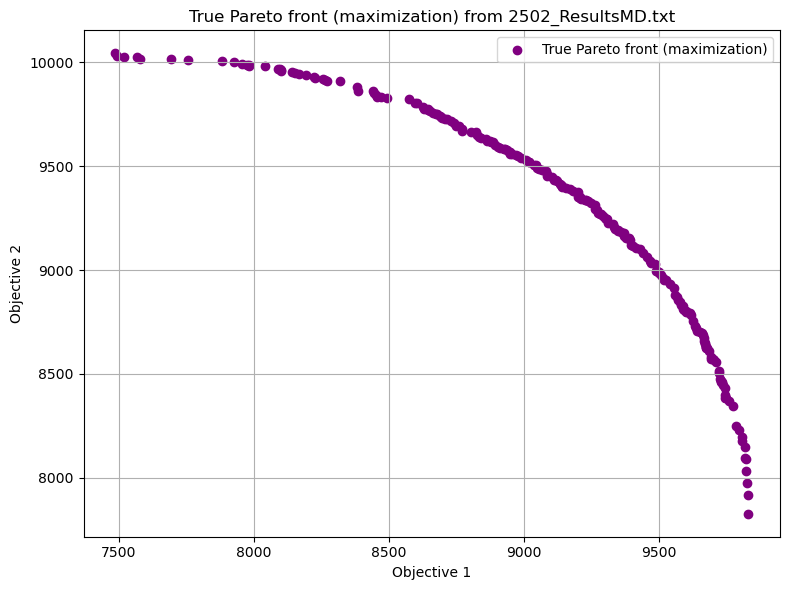

In [5]:
import matplotlib.pyplot as plt

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def plot_true_pareto_front(filename):
    # Read all points from the file
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                points.append([float(x) for x in line.split()])
    # Get Pareto front
    pareto = get_true_pareto_front(points)
    xs, ys = zip(*pareto)
    plt.figure(figsize=(8,6))
    plt.scatter(xs, ys, color='purple', label="True Pareto front (maximization)")
    plt.xlabel("Objective 1")
    plt.ylabel("Objective 2")
    plt.title(f"True Pareto front (maximization) from {filename}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_true_pareto_front("2502_ResultsMD.txt")

In [6]:
def dominates(a, b):
    # Maximization
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def report_pareto_stats(filename):
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except Exception:
                    pass # skip malformed lines
    total_points = len(points)
    pareto_front = get_true_pareto_front(points)
    num_pareto = len(pareto_front)
    print(f"{filename}:")
    print(f"  Total points: {total_points}")
    print(f"  Pareto-optimal points: {num_pareto}")

if __name__ == "__main__":
    # Change these filenames to your actual result files
    files = [
        "2502_ResultsMD.txt",
        "5002_ResultsMD.txt",
        "7502_ResultsMD.txt"
    ]
    for filename in files:
        report_pareto_stats(filename)

2502_ResultsMD.txt:
  Total points: 1413
  Pareto-optimal points: 212
5002_ResultsMD.txt:
  Total points: 2241
  Pareto-optimal points: 369
7502_ResultsMD.txt:
  Total points: 2927
  Pareto-optimal points: 552


In [7]:
run_moacp(b"250.3.txt", b"Weights_3obj_FQ100.txt", 250, 3, "2503_ResultsMD.txt")
run_moacp(b"500.3.txt", b"Weights_3obj_FQ100.txt", 500, 3, "5003_ResultsMD.txt")
run_moacp(b"750.3.txt", b"Weights_3obj_FQ100.txt", 750, 3, "7503_ResultsMD.txt")

RUN 1/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 2/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 3/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 4/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 5/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 6/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 7/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 8/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 9/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 10/10 -- 250.3.txt nbitems=250 nf=3 => 2503_ResultsMD.txt
RUN 1/10 -- 500.3.txt nbitems=500 nf=3 => 5003_ResultsMD.txt
RUN 2/10 -- 500.3.txt nbitems=500 nf=3 => 5003_ResultsMD.txt
RUN 3/10 -- 500.3.txt nbitems=500 nf=3 => 5003_ResultsMD.txt
RUN 4/10 -- 500.3.txt nbitems=500 nf=3 => 5003_ResultsMD.txt
RUN 5/10 -- 500.3.txt nbitems=500 nf=3 => 5003_ResultsMD.txt
RUN 6/10 -- 500.3.txt nbitems=500 nf=3 => 5003_ResultsMD.txt
RUN 7/10 -- 500.3.txt n

In [8]:
def dominates(a, b):
    # Maximization
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def report_pareto_stats(filename):
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except Exception:
                    pass # skip malformed lines
    total_points = len(points)
    pareto_front = get_true_pareto_front(points)
    num_pareto = len(pareto_front)    

    print(f"{filename}:")
    print(f"  Total points: {total_points}")
    print(f"  Pareto-optimal points: {num_pareto}")    

if __name__ == "__main__":
    # Change these filenames to your actual result files
    files = [
        "2503_ResultsMD.txt",
        "5003_ResultsMD.txt",
        "7503_ResuLtsMD.txt"
    ]
    for filename in files:
        report_pareto_stats(filename)

2503_ResultsMD.txt:
  Total points: 8236
  Pareto-optimal points: 2827
5003_ResultsMD.txt:
  Total points: 14778
  Pareto-optimal points: 5357
7503_ResuLtsMD.txt:
  Total points: 20573
  Pareto-optimal points: 7540


In [9]:
run_moacp(b"250.4.txt", b"Weights_4obj_FQ40.txt", 250, 4, "2504_ResultsMD.txt")
run_moacp(b"500.4.txt", b"Weights_4obj_FQ40.txt", 500, 4, "5004_ResultsMD.txt")
run_moacp(b"750.4.txt", b"Weights_4obj_FQ40.txt", 750, 4, "7504_ResultsMD.txt")

RUN 1/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 2/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 3/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 4/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 5/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 6/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 7/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 8/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 9/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 10/10 -- 250.4.txt nbitems=250 nf=4 => 2504_ResultsMD.txt
RUN 1/10 -- 500.4.txt nbitems=500 nf=4 => 5004_ResultsMD.txt
RUN 2/10 -- 500.4.txt nbitems=500 nf=4 => 5004_ResultsMD.txt
RUN 3/10 -- 500.4.txt nbitems=500 nf=4 => 5004_ResultsMD.txt
RUN 4/10 -- 500.4.txt nbitems=500 nf=4 => 5004_ResultsMD.txt
RUN 5/10 -- 500.4.txt nbitems=500 nf=4 => 5004_ResultsMD.txt
RUN 6/10 -- 500.4.txt nbitems=500 nf=4 => 5004_ResultsMD.txt
RUN 7/10 -- 500.4.txt n

In [11]:
def dominates(a, b):
    # Maximization
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def report_pareto_stats(filename):
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    points.append([float(x) for x in line.split()])
                except Exception:
                    pass # skip malformed lines
    total_points = len(points)
    pareto_front = get_true_pareto_front(points)
    num_pareto = len(pareto_front)    
    
    print(f"{filename}:")
    print(f"  Total points: {total_points}")
    print(f"  Pareto-optimal points: {num_pareto}")
  

if __name__ == "__main__":
    # Change these filenames to your actual result files
    files = [
        "2504_ResultsMD.txt",
        "5004_ResultsMD.txt",
        "7504_ResultsMD.txt"
    ]
    for filename in files:
        report_pareto_stats(filename)

2504_ResultsMD.txt:
  Total points: 10883
  Pareto-optimal points: 5594
5004_ResultsMD.txt:
  Total points: 20087
  Pareto-optimal points: 10239
7504_ResultsMD.txt:
  Total points: 28667
  Pareto-optimal points: 16003
